In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm

In [3]:
# Load CSV (ignore datetime index, just use row numbers)
df = pd.read_csv("nvda_stock_clean.csv")

In [4]:
print(df.head())

         date ticker      open      high       low     close      volume  \
0  1999-01-22   NVDA  0.040018  0.044663  0.035492  0.037517  2714688000   
1  1999-01-25   NVDA  0.040494  0.041923  0.037517  0.041448   510480000   
2  1999-01-26   NVDA  0.041923  0.042757  0.037636  0.038231   343200000   
3  1999-01-27   NVDA  0.038350  0.039303  0.036206  0.038113   244368000   
4  1999-01-28   NVDA  0.038113  0.038350  0.037755  0.037993   227520000   

   daily_return_pct  log_return  intraday_return_pct  daily_range_pct  \
0               NaN         NaN            -6.249138        22.916564   
1         10.476402    0.099632             2.353687        10.880707   
2         -7.759382   -0.080770            -8.805878        12.216088   
3         -0.311020   -0.003115            -0.620124         8.075938   
4         -0.314385   -0.003149            -0.314397         1.562383   

   overnight_gap_pct  sma_20  sma_50  volatility_20_pct  volume_sma_20  \
0                NaN     NaN  

In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 6958 entries, 0 to 6957
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 6958 non-null   str    
 1   ticker               6958 non-null   str    
 2   open                 6958 non-null   float64
 3   high                 6958 non-null   float64
 4   low                  6958 non-null   float64
 5   close                6958 non-null   float64
 6   volume               6958 non-null   int64  
 7   daily_return_pct     6957 non-null   float64
 8   log_return           6957 non-null   float64
 9   intraday_return_pct  6958 non-null   float64
 10  daily_range_pct      6958 non-null   float64
 11  overnight_gap_pct    6957 non-null   float64
 12  sma_20               6939 non-null   float64
 13  sma_50               6909 non-null   float64
 14  volatility_20_pct    6938 non-null   float64
 15  volume_sma_20        6939 non-null   float64
 16 

In [6]:
print(df.describe())

              open         high          low        close        volume  \
count  6958.000000  6958.000000  6958.000000  6958.000000  6.958000e+03   
mean     18.366392    18.662561    18.038694    18.360151  5.754485e+08   
std      46.024601    46.706006    45.248781    45.987669  4.293559e+08   
min       0.031919     0.032515     0.030490     0.031205  1.968000e+07   
25%       0.266862     0.273951     0.259859     0.266862  3.082920e+08   
50%       0.460818     0.467353     0.453466     0.460596  4.785860e+08   
75%       6.169095     6.248986     6.093402     6.158870  7.117710e+08   
max     232.849448   236.000556   229.373344   235.202393  9.230856e+09   

       daily_return_pct   log_return  intraday_return_pct  daily_range_pct  \
count       6957.000000  6957.000000          6958.000000      6958.000000   
mean           0.194226     0.001252             0.038186         4.217955   
std            3.727403     0.037119             3.152345         2.956618   
min         

In [7]:
# Use 'close' column as price series
nvda = df[['close']].dropna().copy()
nvda.rename(columns={'close': 'Close'}, inplace=True)

In [8]:
# -------------------------------
# Regression Model
# -------------------------------
nvda['Lag1'] = nvda['Close'].shift(1)
nvda['Lag2'] = nvda['Close'].shift(2)
nvda = nvda.dropna()

In [9]:
X = nvda[['Lag1','Lag2']]
y = nvda['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

In [10]:
rmse_reg = np.sqrt(mean_squared_error(y_test, y_pred))
mae_reg = mean_absolute_error(y_test, y_pred)
print("Regression RMSE:", rmse_reg)
print("Regression MAE:", mae_reg)

Regression RMSE: 2.9868998475278645
Regression MAE: 1.8434866067311497


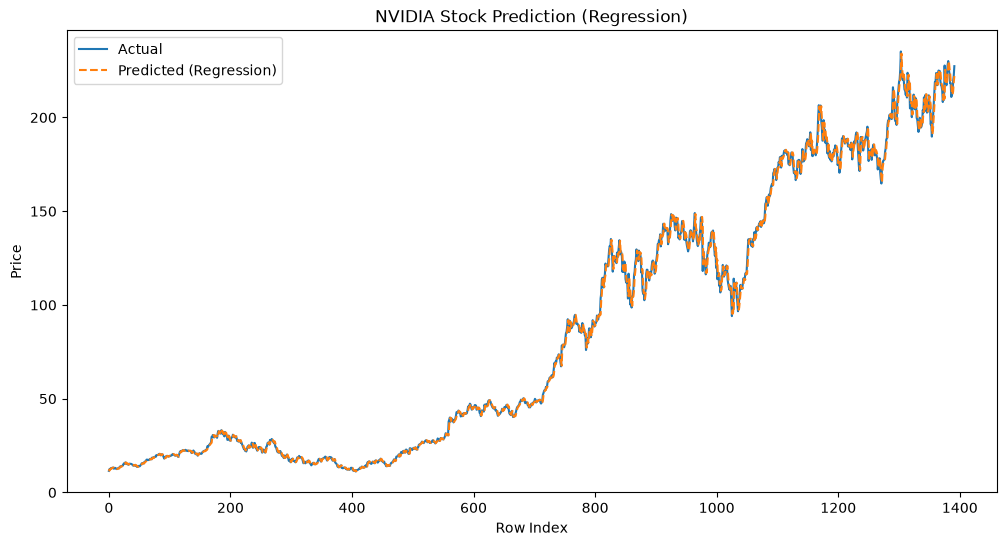

In [11]:
plt.figure(figsize=(12,6))
plt.plot(range(len(y_test)), y_test, label="Actual")
plt.plot(range(len(y_test)), y_pred, label="Predicted (Regression)", linestyle="--")
plt.title("NVIDIA Stock Prediction (Regression)")
plt.xlabel("Row Index")
plt.ylabel("Price")
plt.legend()
plt.show()